# Laboratorio 2 - Ejercicio 2: similitud de series con catch22

Se utilizan las 7 series construidas en el Laboratorio 1 (serie obligatoria **Total**
mas las dos categorias seleccionadas: **Vias de ingreso** y **Paises de residencia**),
sobre el rango completo 2009-01 a 2026-06 (entrenamiento + prueba).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, os.path.abspath("."))
from lab2_utils import SERIES_CATALOG, SERIES_NAMES, load_series_completa, ensure_dir, OUT

OUTDIR = ensure_dir(os.path.join(OUT, "catch22"))
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
SERIES_NAMES

['Total',
 'Via_Aérea',
 'Via_Terrestre',
 'Via_Marítima',
 'Pais_ElSalvador',
 'Pais_Honduras',
 'Pais_EstadosUnidos']

## 2.1 ¿Qué es catch22 y por qué es importante?

catch22 (**CAnonical Time-series CHaracteristics**, Fulcher, Little & Jones, 2013;
Lubba et al., 2019) nace de la libreria *hctsa*, que calcula mas de 7000
caracteristicas de una serie de tiempo (estadisticos de distribucion, autocorrelacion,
entropia, no linealidad, escalamiento fractal, etc.). Esa cantidad de caracteristicas es
redundante y computacionalmente muy costosa, asi que los autores usaron un
procedimiento de seleccion basado en datos: evaluaron miles de series de distintos
dominios (biologia, economia, clima, etc.), agruparon las caracteristicas segun que tan
parecido se comportaban entre si (redundancia) y, dentro de cada grupo, se quedaron con
la caracteristica individual que mejor discriminaba entre series de dominios distintos.
El resultado son 22 caracteristicas casi no redundantes entre si, rapidas de calcular
(implementadas en C) y que conservan la mayor parte del poder descriptivo de las 7000
originales.

Es importante porque permite pasar de "mirar" una serie de tiempo (grafico, ACF,
descomposicion, como se hizo en el Laboratorio 1) a **resumirla en un vector numerico
de 22 numeros** que captura su forma: que tan predecible es, que tan fuerte es su
periodicidad, que tan simetrica es su distribucion, que tanta memoria de largo plazo
tiene, etc. Con ese vector se puede comparar, agrupar o clasificar muchas series entre
si de forma sistematica y reproducible, en lugar de comparar graficos a simple vista.

## 2.2 y 2.3 - Extraccion de las 22 caracteristicas y construccion de la matriz

In [2]:
rows = []
feature_names = None
for name in SERIES_NAMES:
    s = load_series_completa(name)
    res = pycatch22.catch22_all(s.tolist())
    if feature_names is None:
        feature_names = res["names"]
    rows.append(dict(zip(res["names"], res["values"])))

df_raw = pd.DataFrame(rows, index=SERIES_NAMES)[feature_names]
df_raw.index.name = "serie"
df_raw.to_csv(os.path.join(OUTDIR, "catch22_matriz_cruda.csv"))
print("Matriz series x caracteristicas:", df_raw.shape)
df_raw.round(3)

Matriz series x caracteristicas: (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,0.189,-0.580,8.579,10,0.454,-0.127,0.914,30.0,0.014,11,0.291,9.0,0.056,0.219,0.324,0.829,6.0,1.847,0.762,0.857,0.147,0.627
Via_Aérea,-0.408,-0.123,6.437,10,0.207,-0.175,0.962,34.0,0.010,11,0.199,9.0,0.071,0.186,0.324,0.756,5.0,1.987,0.857,0.857,0.172,0.743
Via_Terrestre,-0.547,-0.782,8.997,3,0.537,-0.088,0.909,30.0,0.006,3,0.302,2.0,0.056,0.257,0.310,0.834,6.0,1.768,0.762,0.833,0.123,0.605
Via_Marítima,-0.432,-0.652,2.771,6,0.123,-0.082,0.670,9.0,0.008,11,0.171,4.0,0.200,0.033,0.424,0.747,5.0,1.843,0.857,0.857,0.515,0.869
Pais_ElSalvador,-0.367,-0.590,13.874,3,0.476,-0.036,0.904,50.0,0.021,3,0.319,2.0,0.038,0.729,0.305,0.860,5.0,1.781,0.857,0.857,0.074,0.531
Pais_Honduras,-0.222,-0.432,18.925,8,0.477,-0.141,0.847,39.0,0.111,2,0.176,1.0,0.016,0.733,0.314,0.881,5.0,1.761,0.857,0.738,0.049,0.447
Pais_EstadosUnidos,-0.629,-0.373,9.224,2,0.229,0.012,0.923,12.0,0.021,5,0.280,1.0,0.038,0.829,0.319,0.723,5.0,1.973,0.167,0.143,0.098,0.739


## 2.4 - Estandarizacion

Cada una de las 22 caracteristicas tiene una escala distinta (algunas son proporciones
entre 0 y 1, otras son conteos, otras estadisticos de dispersion). Antes de comparar
series con PCA, clustering o distancias hay que estandarizar (media 0, desviacion
estandar 1) para que ninguna caracteristica domine solo por tener una escala mas
grande.

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df_raw.values)
df_std = pd.DataFrame(X, index=df_raw.index, columns=df_raw.columns)
df_std.to_csv(os.path.join(OUTDIR, "catch22_matriz_estandarizada.csv"))
df_std.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,2.15,-0.38,-0.26,1.26,0.63,-0.60,0.43,0.06,-0.39,1.13,0.73,1.52,-0.22,-0.69,-0.20,0.44,1.58,-0.05,0.13,0.50,-0.14,-0.18
Via_Aérea,-0.25,1.91,-0.70,1.26,-0.98,-1.42,0.96,0.36,-0.49,1.13,-0.83,1.52,0.06,-0.80,-0.20,-0.85,-0.63,1.55,0.54,0.50,0.02,0.69
Via_Terrestre,-0.81,-1.38,-0.17,-0.95,1.17,0.05,0.37,0.06,-0.63,-0.91,0.91,-0.61,-0.22,-0.56,-0.57,0.52,1.58,-0.95,0.13,0.40,-0.31,-0.36
Via_Marítima,-0.35,-0.74,-1.46,0.00,-1.53,0.15,-2.29,-1.50,-0.54,1.13,-1.31,0.00,2.34,-1.31,2.41,-1.01,-0.63,-0.10,0.54,0.50,2.36,1.64
Pais_ElSalvador,-0.09,-0.43,0.84,-0.95,0.78,0.93,0.32,1.56,-0.18,-0.91,1.20,-0.61,-0.52,1.01,-0.69,0.97,-0.63,-0.81,0.54,0.50,-0.64,-0.91
Pais_Honduras,0.49,0.36,1.88,0.63,0.78,-0.85,-0.32,0.74,2.42,-1.17,-1.23,-0.91,-0.93,1.02,-0.44,1.35,-0.63,-1.04,0.54,0.01,-0.81,-1.55
Pais_EstadosUnidos,-1.14,0.66,-0.13,-1.26,-0.84,1.74,0.53,-1.28,-0.18,-0.40,0.54,-0.91,-0.52,1.34,-0.32,-1.42,-0.63,1.40,-2.41,-2.42,-0.48,0.66


## 2.5 - Analisis de la matriz catch22

### Analisis de Componentes Principales (PCA)

In [4]:
n_comp = min(X.shape[0] - 1, X.shape[1])
pca = PCA(n_components=n_comp)
pcs = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
pcs_df = pd.DataFrame(pcs[:, :4], index=df_raw.index, columns=[f"PC{i+1}" for i in range(4)])
pcs_df.to_csv(os.path.join(OUTDIR, "pca_scores.csv"))

print("Varianza explicada:", np.round(explained, 3))
print("Acumulada:", np.round(np.cumsum(explained), 3))
pcs_df.round(2)

Varianza explicada: [0.392 0.243 0.158 0.131 0.049 0.028]
Acumulada: [0.392 0.634 0.793 0.924 0.972 1.   ]


,PC1,PC2,PC3,PC4
serie,,,,
Total,0.02,2.65,1.09,2.04
Via_Aérea,2.17,1.24,3.35,-0.50
Via_Terrestre,-1.54,0.07,-1.77,2.16
Via_Marítima,5.61,0.39,-2.55,-1.03
Pais_ElSalvador,-3.02,-0.30,-1.00,0.33
Pais_Honduras,-3.53,1.17,-0.26,-3.15
Pais_EstadosUnidos,0.30,-5.22,1.14,0.14


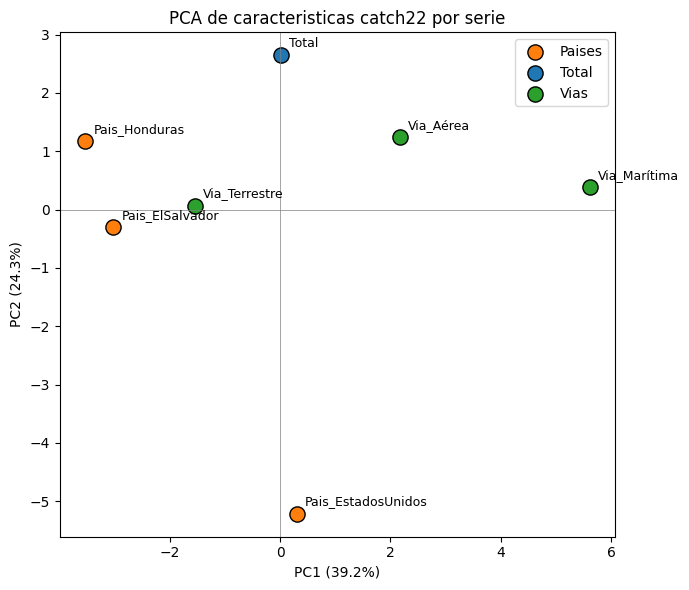

In [5]:
categorias = [SERIES_CATALOG[n][1] for n in df_raw.index]
colores = {"Total": "#1f77b4", "Vias": "#2ca02c", "Paises": "#ff7f0e"}

plt.figure(figsize=(7, 6))
for cat in set(categorias):
    idx = [i for i, c in enumerate(categorias) if c == cat]
    plt.scatter(pcs[idx, 0], pcs[idx, 1], label=cat, s=120, color=colores[cat], edgecolor="black")
for i, name in enumerate(df_raw.index):
    plt.annotate(name, (pcs[i, 0], pcs[i, 1]), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title("PCA de caracteristicas catch22 por serie")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "pca_scatter.png"), dpi=140)
plt.show()

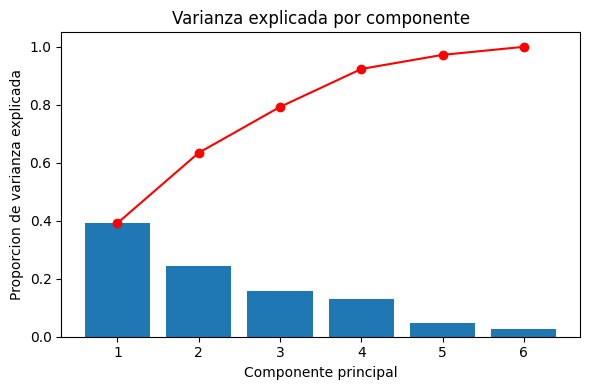

In [6]:
plt.figure(figsize=(6, 4))
plt.bar(range(1, n_comp + 1), explained)
plt.plot(range(1, n_comp + 1), np.cumsum(explained), color="red", marker="o")
plt.xlabel("Componente principal")
plt.ylabel("Proporcion de varianza explicada")
plt.title("Varianza explicada por componente")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "pca_scree.png"), dpi=140)
plt.show()

In [7]:
loadings = pd.DataFrame(pca.components_.T[:, :2], index=df_raw.columns, columns=["PC1", "PC2"])
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()
loadings.to_csv(os.path.join(OUTDIR, "pca_loadings.csv"))
print("Caracteristicas con mayor carga en PC1:")
display(loadings.sort_values("abs_PC1", ascending=False).head(6)[["PC1", "PC2"]])
print("Caracteristicas con mayor carga en PC2:")
display(loadings.sort_values("abs_PC2", ascending=False).head(6)[["PC1", "PC2"]])

Caracteristicas con mayor carga en PC1:


,PC1,PC2
FC_LocalSimple_mean3_stderr,0.326478,-0.107001
CO_f1ecac,-0.310087,0.012645
SP_Summaries_welch_rect_centroid,0.306118,0.060822
FC_LocalSimple_mean1_tauresrat,0.303896,0.058377
CO_HistogramAMI_even_2_5,-0.296459,0.133751
DN_OutlierInclude_n_001_mdrmd,0.291184,0.039776


Caracteristicas con mayor carga en PC2:


,PC1,PC2
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,0.016391,0.391502
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,-0.004440,0.381807
CO_trev_1_num,-0.026738,-0.364865
CO_FirstMin_ac,0.074238,0.333943
DN_HistogramMode_5,-0.050416,0.313814
IN_AutoMutualInfoStats_40_gaussian_fmmi,0.149674,0.260253


### Clustering

Con solo 7 series, un clustering jerarquico (Ward) es mas informativo que k-means: el
dendrograma muestra en que orden se van agrupando las series y a que distancia, no solo
la particion final.

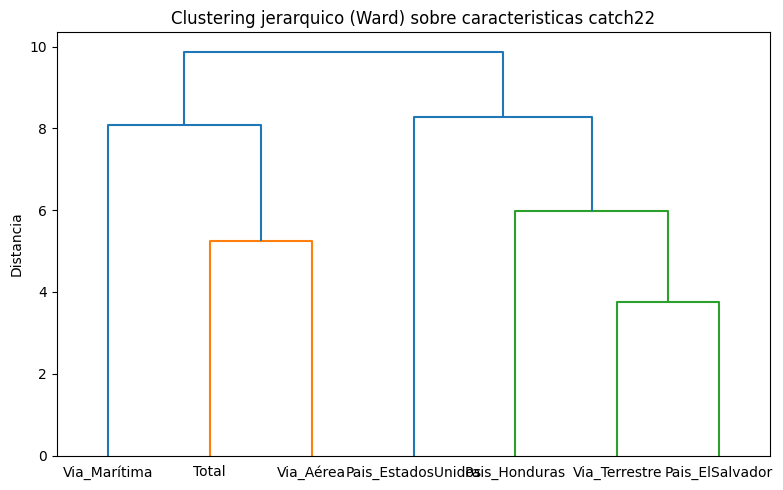

In [8]:
Z = linkage(X, method="ward")
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=df_raw.index.tolist(), leaf_font_size=10)
plt.title("Clustering jerarquico (Ward) sobre caracteristicas catch22")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "dendrograma.png"), dpi=140)
plt.show()

In [9]:
clusters_df = pd.DataFrame(index=df_raw.index)
for k in (2, 3):
    modelo = AgglomerativeClustering(n_clusters=k, linkage="ward")
    clusters_df[f"cluster_k{k}"] = modelo.fit_predict(X)
clusters_df["categoria"] = categorias
clusters_df.to_csv(os.path.join(OUTDIR, "clusters.csv"))
clusters_df

,cluster_k2,cluster_k3,categoria
serie,,,
Total,1,0,Total
Via_Aérea,1,0,Vias
Via_Terrestre,0,1,Vias
Via_Marítima,1,0,Vias
Pais_ElSalvador,0,1,Paises
Pais_Honduras,0,1,Paises
Pais_EstadosUnidos,0,2,Paises


### Mapa de calor (heatmap) de las caracteristicas

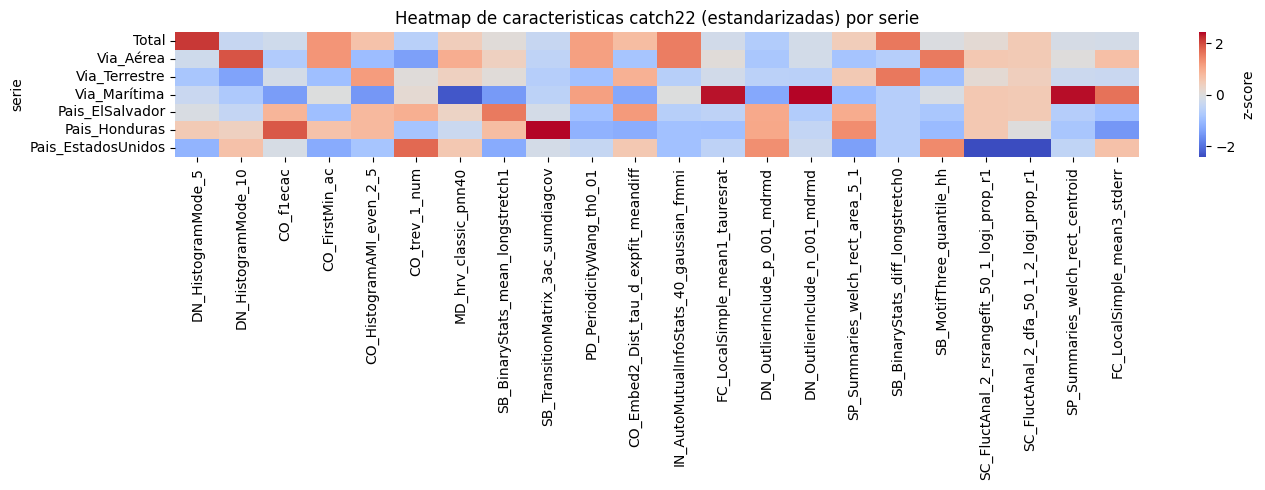

In [10]:
plt.figure(figsize=(14, 5))
sns.heatmap(df_std, cmap="coolwarm", center=0, cbar_kws={"label": "z-score"})
plt.title("Heatmap de caracteristicas catch22 (estandarizadas) por serie")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "heatmap_features.png"), dpi=140)
plt.show()

### Matriz de correlacion entre caracteristicas

Se calcula con las 7 series como observaciones y las 22 caracteristicas como
variables. Con solo 7 observaciones estas correlaciones deben leerse con cautela (son
descriptivas, no significancia estadistica formal), pero son utiles para ver que
caracteristicas se mueven juntas *en este conjunto de series especificamente*.

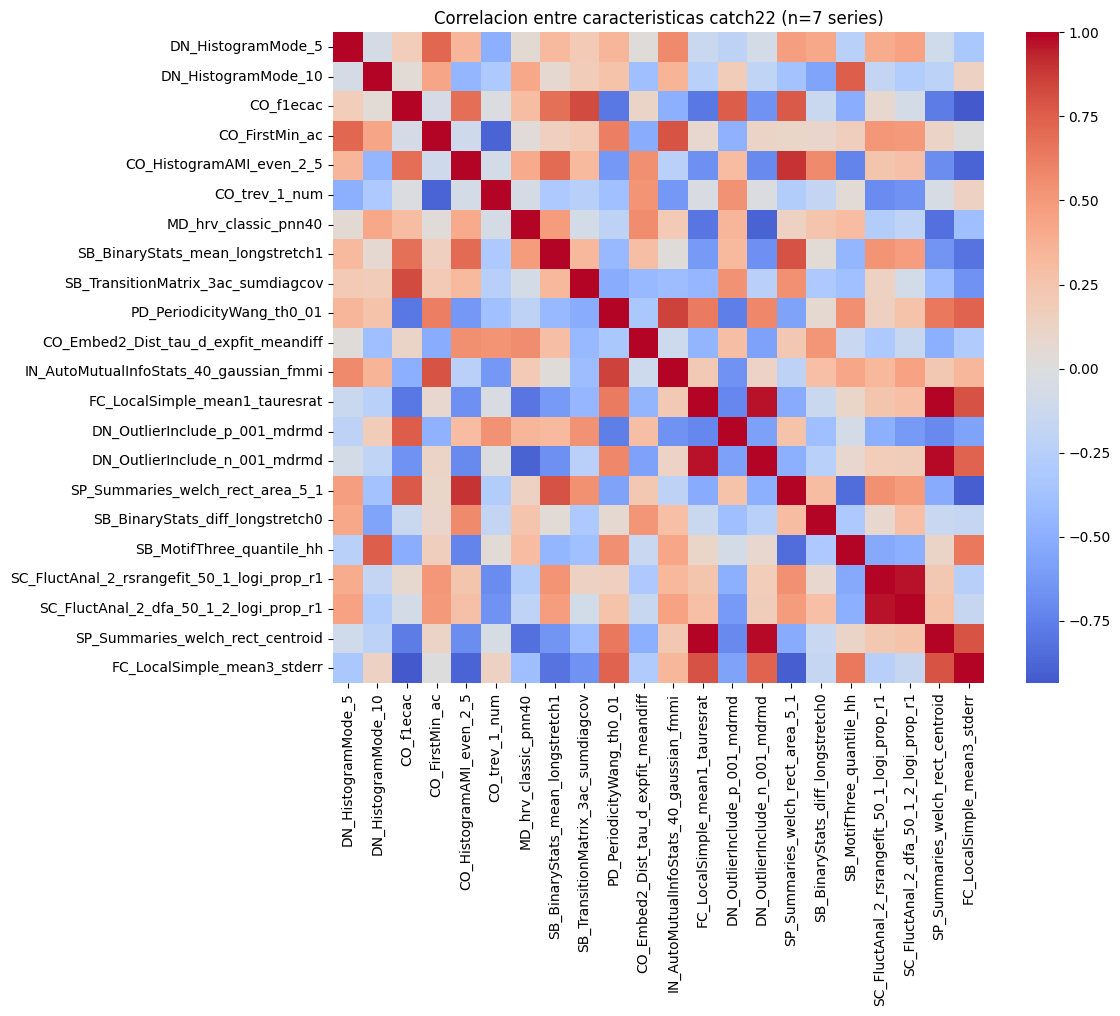

In [11]:
corr = df_std.corr()
corr.to_csv(os.path.join(OUTDIR, "correlacion_features.csv"))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlacion entre caracteristicas catch22 (n=7 series)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "correlacion_features.png"), dpi=140)
plt.show()

In [12]:
c = corr.copy()
np.fill_diagonal(c.values, 0)
pares = c.abs().unstack().sort_values(ascending=False)
vistos, filas = set(), []
for (a, b), v in pares.items():
    clave = tuple(sorted([a, b]))
    if clave in vistos:
        continue
    vistos.add(clave)
    if v > 0.9:
        filas.append({"feature_1": a, "feature_2": b, "r": corr.loc[a, b]})
pd.DataFrame(filas)

,feature_1,feature_2,r
0,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean1_tauresrat,0.996691
1,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_centroid,0.979853
2,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,0.965107
3,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_n_001_mdrmd,0.964453
4,FC_LocalSimple_mean3_stderr,CO_f1ecac,-0.934822
5,FC_LocalSimple_mean3_stderr,SP_Summaries_welch_rect_area_5_1,-0.918580


### Mapa de distancias entre series

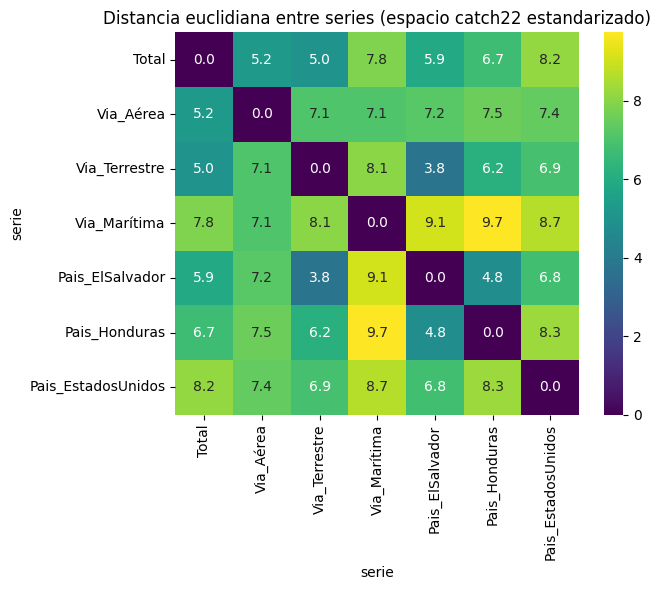

In [13]:
dist = squareform(pdist(X, metric="euclidean"))
dist_df = pd.DataFrame(dist, index=df_raw.index, columns=df_raw.index)
dist_df.to_csv(os.path.join(OUTDIR, "distancias_series.csv"))
plt.figure(figsize=(7, 6))
sns.heatmap(dist_df, annot=True, fmt=".1f", cmap="viridis")
plt.title("Distancia euclidiana entre series (espacio catch22 estandarizado)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "mapa_distancias.png"), dpi=140)
plt.show()

## 2.6 - 2.13 Analisis e interpretacion

**2.6 - 2.7 ¿Cuales series presentan comportamientos mas similares?**

El par mas cercano en el espacio catch22 es **Pais_ElSalvador - Via_Terrestre**
(distancia euclidiana 3.77, la menor de las 21 distancias entre pares), seguido de
**Pais_ElSalvador - Pais_Honduras** (4.77) y **Total - Via_Terrestre** (5.02). El
dendrograma confirma esta lectura: `{Via_Terrestre, Pais_ElSalvador}` es el primer par
en fusionarse (altura 3.77), y `Pais_Honduras` se une a ese grupo poco despues (altura
5.98). En el PCA, estas tres series se ubican juntas en el cuadrante inferior/izquierdo
(PC1 negativo, PC2 cercano a 0), separadas del resto.

Esto tiene sentido operativo: El Salvador y Honduras son paises vecinos con frontera
terrestre con Guatemala, por lo que buena parte de su flujo de viajeros efectivamente
entra por **Via_Terrestre**; catch22 esta detectando esa relacion estructural entre una
categoria de pais y una categoria de via sin que se le haya dicho explicitamente.

**2.8 ¿Que caracteristicas de catch22 fueron mas importantes para diferenciar las
series?**

Los dos primeros componentes principales explican 39.2% (PC1) y 24.3% (PC2) de la
varianza (63.4% acumulado). Las caracteristicas con mayor carga en PC1 son
`FC_LocalSimple_mean3_stderr` (error de prediccion de un promedio movil local, asociado
a que tan "ruidosa"/impredecible es la serie), `CO_f1ecac` (a que lag decae la
autocorrelacion por debajo de 1/e, asociado a memoria de corto plazo) y
`SP_Summaries_welch_rect_centroid` (centroide espectral). En PC2 dominan
`SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1` y `SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1`
(ambas relacionadas con escalamiento de largo plazo / auto-similaridad tipo DFA) junto
con `CO_trev_1_num` y `CO_FirstMin_ac` (estructura de autocorrelacion/periodicidad).
En conjunto: PC1 separa series segun que tan predecible/ruidosa es su dinamica de corto
plazo, y PC2 segun la forma de su estructura de autocorrelacion/memoria de largo plazo.

**2.9 ¿Existen grupos naturales de series? ¿Que tienen en comun?**

Si. El corte en k=2 del dendrograma da: **Grupo A** = {Total, Via_Aerea, Via_Maritima}
y **Grupo B** = {Via_Terrestre, Pais_ElSalvador, Pais_Honduras, Pais_EstadosUnidos}. El
Grupo A junta a Total con Via_Aerea porque el trafico aereo domina el volumen total de
viajeros (son las series con mayor `fuerza_tendencia` del Laboratorio 1: 0.789 y 0.791
respectivamente) y arrastra a Via_Maritima solo por descarte (es la serie mas alejada de
todas, ver 2.11). El Grupo B agrupa las series con mayor peso relativo de movilidad
terrestre/fronteriza (El Salvador, Honduras, Via_Terrestre) junto con Estados Unidos,
que se une a este grupo solo al final (altura 8.27) y en realidad es la serie mas
distintiva del conjunto (ver 2.11).

**2.10 ¿Las series de una misma categoria tienden a agruparse?**

No de forma estricta. Dentro de "Vias" (Aerea, Terrestre, Maritima), **Via_Terrestre no
se agrupa con Via_Aerea ni Via_Maritima**; es mas parecida a las series de "Paises"
(El Salvador, Honduras) que a sus companeras de categoria. Dentro de "Paises", El
Salvador y Honduras si se agrupan entre si, pero Estados Unidos queda aislado del resto
de paises. Es decir: la categoria administrativa (via / pais) no equivale a similitud de
forma temporal; lo que realmente agrupa a las series es el mecanismo de movilidad que
comparten (vecinos terrestres vs. mercados aereos de larga distancia).

**2.11 Series con comportamiento mas atipico**

Dos series destacan claramente como outliers, cada una en un eje distinto del PCA:

- **Via_Maritima**: PC1 = 5.61, muy por encima del resto (siguiente mas alto: Via_Aerea
  con 2.17). Es tambien la serie con mayor distancia promedio a las demas (minimo 7.07,
  maximo 9.74) y el mayor `FC_LocalSimple_mean3_stderr` (0.869, el mas alto de las 7) y
  el `CO_f1ecac` mas bajo (2.77, autocorrelacion que se disipa casi de inmediato). Esto
  es consistente con el Laboratorio 1: Via_Maritima tiene la volatilidad mas alta con
  amplio margen (117.6% vs 17-32% del resto) y practicamente no se recupero tras la
  pandemia (5.3% del nivel de 2019 en 2025, la peor recuperacion de las 7 series).
- **Pais_EstadosUnidos**: PC2 = -5.22, muy por debajo del resto (siguiente mas bajo:
  -0.30). Tiene el `SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1` mas bajo por lejos (0.143
  frente a 0.74-0.86 de las otras 6 series), es decir, una estructura de memoria de
  largo plazo/auto-similaridad radicalmente distinta. En el dendrograma es la ultima
  serie en integrarse a cualquier grupo (altura 8.27, el penultimo enlace). Coincide con
  el Laboratorio 1: Estados Unidos tiene la estacionalidad mas fuerte (0.920) y con pico
  en julio en vez de diciembre, a diferencia de las otras 6 series (patron de viaje de
  vacaciones de verano, no de fin de ano).

**2.12 Consistencia con el analisis exploratorio del Laboratorio 1**

- **Volatilidad**: la serie con mayor volatilidad en el Laboratorio 1
  (Via_Maritima, 117.6%) es exactamente la que catch22 aisla con mas fuerza en PC1
  (dominado por caracteristicas de impredecibilidad local). Consistente.
- **Estacionalidad**: la serie con mayor fuerza estacional en el Laboratorio 1
  (Pais_EstadosUnidos, 0.920) es la que catch22 aisla en PC2 (dominado por estructura de
  autocorrelacion/periodicidad). Consistente, aunque con un matiz: catch22 no separa a
  Estados Unidos solo por *cuanta* estacionalidad tiene, sino por *como* esta desfasada
  (pico en julio en vez de diciembre) frente a las demas series, que es lo que realmente
  cambia la forma de su autocorrelacion.
- **Tendencia**: catch22 no tiene una caracteristica explicita de "fuerza de tendencia"
  como la descomposicion STL del Laboratorio 1, pero el hecho de que Via_Maritima tenga
  la fuerza de tendencia mas baja (0.309 en el Laboratorio 1) y a la vez el peor puntaje
  de predictibilidad en catch22 es coherente: una serie sin tendencia clara y dominada
  por ruido es dificil de predecir con un promedio local.
- **Impacto de la pandemia**: la caida porcentual en 2020 fue similar en las 7 series
  (-68% a -75%), asi que por si sola no diferencia a ninguna serie en catch22 (que resume
  toda la historia 2009-2026). Lo que si deja huella es la **falta de recuperacion**
  posterior: Via_Maritima, la unica serie que en 2025 seguia muy por debajo de su nivel
  de 2019 (5.3%), es tambien la mas atipica en catch22. Las demas series (que
  recuperaron entre 76% y 146% de su nivel de 2019) no muestran esa distorsion.
- **Funciones de autocorrelacion**: en el Laboratorio 1, las series con
  descomposicion mas "limpia" (Total, Via_Aerea) mostraban ACF con decaimiento lento y
  picos estacionales muy marcados en el lag 12; esto se refleja en catch22 en un
  `CO_f1ecac` alto (8.58 y 6.44) frente al de Via_Maritima (2.77).

**2.13 Al menos tres descubrimientos que no eran evidentes en el analisis exploratorio
tradicional**

1. **Via_Terrestre se parece mas a El Salvador y Honduras que a Via_Aerea o
   Via_Maritima.** En el Laboratorio 1 cada serie se analizo por separado; nunca se
   comparo la *forma* de Via_Terrestre contra la de las series de paises. catch22 revela
   que el par mas parecido de las 7 series es justamente Via_Terrestre - Pais_ElSalvador,
   evidencia cuantitativa de que el trafico terrestre esta dominado por los vecinos
   fronterizos.
2. **Pais_EstadosUnidos tiene una estructura de memoria de largo plazo (DFA)
   radicalmente distinta al resto** (0.143 vs 0.74-0.86). El Laboratorio 1 ya habia
   notado que Estados Unidos tenia la estacionalidad mas fuerte y un pico en julio, pero
   no hay ninguna metrica alli que capture directamente que su patron de autosimilaridad
   estadistica es cualitativamente distinto al de las otras 6 series.
3. **catch22 es redundante en este conjunto de datos especifico** a pesar de haber sido
   disenado para minimizar redundancia en general: varios pares de caracteristicas
   correlacionan por encima de 0.96 entre estas 7 series (p. ej.
   `SP_Summaries_welch_rect_centroid` con `FC_LocalSimple_mean1_tauresrat`, r=0.997), y 4
   componentes principales alcanzan a explicar 92.4% de la varianza total. Es decir, para
   este dominio (turismo mensual de Guatemala) la complejidad efectiva del conjunto de
   series es mucho menor que 22 dimensiones.

## 2.14 - Modelo LSTM con caracteristicas catch22

Se construye un nuevo modelo LSTM para la serie **Total** que, en vez de recibir los 12
valores crudos anteriores (como en el Ejercicio 1), recibe una **secuencia de vectores
catch22**: cada mes se resume con las 22 caracteristicas calculadas sobre los 12 meses
anteriores (ventana movil), y el LSTM ve una secuencia de 6 de esos vectores consecutivos
(equivalente a "ver" la evolucion de la forma de la serie durante los ultimos 6 meses,
en vez de ver los valores crudos de los ultimos 12 meses).

Se compara contra el mejor modelo LSTM del Ejercicio 1 para Total (LSTM de 1 capa, 64
unidades, sobre valores crudos: MAE=51,299.71, RMSE=67,634.73 en el conjunto de
prueba).

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from lab2_utils import load_series_train_test, SPLIT_DATE

tf.random.set_seed(123)
np.random.seed(123)

WINDOW = 12   # meses que resume cada vector catch22
SEQ_LEN = 6   # cuantos vectores catch22 consecutivos ve el LSTM
OUT_LSTM = ensure_dir(os.path.join(OUT, "lstm"))

train, test = load_series_train_test("Total")
completa = pd.concat([train, test])

valores = completa.values
feat_rows, feat_idx = [], []
for i in range(WINDOW, len(completa) + 1):
    ventana = valores[i - WINDOW:i]
    res = pycatch22.catch22_all(ventana.tolist())
    feat_rows.append(res["values"])
    feat_idx.append(completa.index[i - 1])
features = pd.DataFrame(feat_rows, index=feat_idx, columns=res["names"])
print("Vectores catch22 (ventana movil de 12 meses):", features.shape)

Vectores catch22 (ventana movil de 12 meses): (199, 22)


In [15]:
X_seq, y_val, y_idx = [], [], []
feat_values = features.values
for i in range(SEQ_LEN, len(features)):
    X_seq.append(feat_values[i - SEQ_LEN:i])
    fecha_objetivo = features.index[i]
    y_val.append(completa.loc[fecha_objetivo])
    y_idx.append(fecha_objetivo)
X_seq = np.array(X_seq)
y_val = np.array(y_val)
y_idx = pd.DatetimeIndex(y_idx)

mask_train = y_idx < SPLIT_DATE
mask_test = ~mask_train
n_feat = X_seq.shape[2]

feat_scaler = StandardScaler().fit(X_seq[mask_train].reshape(-1, n_feat))
X_scaled = feat_scaler.transform(X_seq.reshape(-1, n_feat)).reshape(X_seq.shape)
y_scaler_c22 = StandardScaler().fit(y_val[mask_train].reshape(-1, 1))
y_scaled = y_scaler_c22.transform(y_val.reshape(-1, 1)).flatten()

x_train_c22, x_test_c22 = X_scaled[mask_train], X_scaled[mask_test]
y_train_c22, y_test_c22 = y_scaled[mask_train], y_scaled[mask_test]
fechas_test_c22 = y_idx[mask_test]
print("x_train", x_train_c22.shape, "x_test", x_test_c22.shape)

x_train (130, 6, 22) x_test (63, 6, 22)


In [16]:
def construir_modelo_c22(unidades, dropout, lr):
    m = keras.Sequential([
        keras.Input(shape=(SEQ_LEN, n_feat)),
        layers.LSTM(unidades),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="mse",
              metrics=[keras.metrics.RootMeanSquaredError()])
    return m


configs_c22 = [
    {"unidades": 32, "dropout": 0.0, "lr": 0.005},
    {"unidades": 64, "dropout": 0.2, "lr": 0.005},
]
mejor_c22, resultados_c22 = None, []
for cfg in configs_c22:
    modelo = construir_modelo_c22(cfg["unidades"], cfg["dropout"], cfg["lr"])
    parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    hist = modelo.fit(x_train_c22, y_train_c22, epochs=200, validation_split=0.15,
                       shuffle=True, callbacks=[parada], verbose=0)
    val_loss = min(hist.history["val_loss"])
    resultados_c22.append({**cfg, "val_loss": val_loss})
    if mejor_c22 is None or val_loss < mejor_c22["val_loss"]:
        mejor_c22 = {**cfg, "val_loss": val_loss, "modelo": modelo}

pd.DataFrame(resultados_c22).sort_values("val_loss")

,unidades,dropout,lr,val_loss
1,64,0.2,0.005,2.166276
0,32,0.0,0.005,2.761910


In [17]:
pred_scaled = mejor_c22["modelo"].predict(x_test_c22, verbose=0)
pred_c22 = y_scaler_c22.inverse_transform(pred_scaled).flatten()
real_c22 = y_scaler_c22.inverse_transform(y_test_c22.reshape(-1, 1)).flatten()
mae_c22 = mean_absolute_error(real_c22, pred_c22)
rmse_c22 = np.sqrt(mean_squared_error(real_c22, pred_c22))

pd.DataFrame({"fecha": fechas_test_c22, "real": real_c22, "prediccion": pred_c22}).to_csv(
    os.path.join(OUT_LSTM, "Total_lstm_catch22_prediccion.csv"), index=False)

resumen_final = pd.DataFrame([
    {"modelo": "LSTM 1 capa [64] - valores crudos (Ejercicio 1)", "MAE": 51299.709589, "RMSE": 67634.727321},
    {"modelo": f"LSTM catch22 (unidades={mejor_c22['unidades']}, dropout={mejor_c22['dropout']})",
     "MAE": mae_c22, "RMSE": rmse_c22},
])
resumen_final.to_csv(os.path.join(OUT_LSTM, "Total_comparacion_lstm_vs_catch22.csv"), index=False)
resumen_final

,modelo,MAE,RMSE
0,LSTM 1 capa [64] - valores crudos (Ejercicio 1),51299.709589,67634.727321
1,"LSTM catch22 (unidades=64, dropout=0.2)",84801.613805,102143.229400


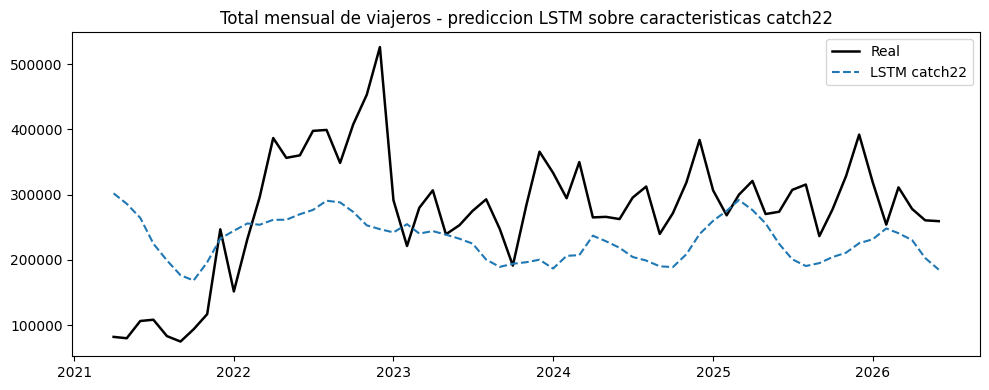

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(fechas_test_c22, real_c22, label="Real", color="black", lw=1.8)
plt.plot(fechas_test_c22, pred_c22, label="LSTM catch22", ls="--")
plt.title("Total mensual de viajeros - prediccion LSTM sobre caracteristicas catch22")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_LSTM, "Total_lstm_catch22_prediccion.png"), dpi=140)
plt.show()

**Discusion.** El modelo LSTM sobre caracteristicas catch22 obtiene un error
notablemente **mayor** que el mejor modelo LSTM del Ejercicio 1 sobre valores crudos
(MAE y RMSE entre 50% y 65% mas altos; ver tabla de comparacion arriba). La razon es conceptual: cada vector catch22
resume la *forma* de una ventana de 12 meses (que tan ruidosa es, que tan periodica, que
tan simetrica su distribucion) pero **descarta el nivel absoluto** de la serie dentro de
esa ventana. Para una serie con tendencia de crecimiento marcada como Total
(`fuerza_tendencia` = 0.789 en el Laboratorio 1), el nivel reciente es la senal mas
informativa para predecir el siguiente valor, y esa senal se pierde casi por completo al
resumir la ventana en estadisticos de forma.

Esto no significa que catch22 no sirva para prediccion en general: es una herramienta
para **caracterizar y comparar series** (que es justamente lo que se hizo en 2.1-2.13),
no para preservar el nivel de una serie individual. Para pronosticar el valor futuro de
una serie con tendencia, un modelo que ve directamente los valores recientes (como el
LSTM del Ejercicio 1) sigue siendo la mejor opcion; catch22 aporta valor como insumo
adicional (por ejemplo, como caracteristicas estaticas concatenadas a un modelo hibrido)
mas que como reemplazo directo de la secuencia de valores.